#  TP FINAL: Parte 01 - Replicando BERT

**negrito**# BERT: Um modelo Transformer de Reconhecimento textual

**Artigo:** BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

**local:** Cornell University


# Modelo




O modelo é Disponibilizado, podendo assim pegarmos no Hugging Face e instanci-lo diretamente.

In [ ]:
# Instala silenciosamente as bibliotecas necessárias, incluindo o scikit-learn para as métricas
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


# Dados

In [ ]:
import torch
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Carregando o Dataset (agora com o namespace completo "nyu-mll/glue" para evitar o HfUriError)
dataset = load_dataset("nyu-mll/glue", "sst2")

# 2. Carregando o Tokenizador pré-treinado do BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Função para converter os textos em tensores.
# Adicionado max_length=128 para otimizar a memória da GPU no Colab
def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

# Aplica a tokenização em lote
tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

# Configuração do Modelo

In [ ]:
# 3. Carregando os pesos do BERT original com uma nova camada final para classificação (Positivo/Negativo)
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# 4. Definindo a métrica de avaliação exigida (Accuracy)
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Fine-Tuning (Loop de Treinamento)

In [ ]:
# 5. Configurando os hiperparâmetros
training_args = TrainingArguments(
    output_dir="./resultados_bert",
    eval_strategy="epoch", # Sintaxe atualizada para evitar avisos de depreciação
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
)

# 6. Inicializando o Trainer
# Mantemos 2000 exemplos de treino para garantir que termine em poucos minutos
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# 7. Executando o Fine-Tuning
print("Iniciando o treinamento...")
trainer.train()

Iniciando o treinamento...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.347615,0.876147


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=125, training_loss=0.5172251586914063, metrics={'train_runtime': 60.5708, 'train_samples_per_second': 33.019, 'train_steps_per_second': 2.064, 'total_flos': 131555527680000.0, 'train_loss': 0.5172251586914063, 'epoch': 1.0})

# Extraindo a Acurácia (Para o seu Relatório)

In [ ]:
# Avalia o modelo no dataset de validação
resultados = trainer.evaluate()

acuracia = resultados['eval_accuracy'] * 100
perda = resultados['eval_loss']

print("-" * 50)
print("RESULTADOS FINAIS PARA O RELATÓRIO")
print("-" * 50)
print(f"Acurácia (Accuracy): {acuracia:.2f}%")
print(f"Loss (Perda): {perda:.4f}")
print("-" * 50)

Training Loss,Validation Loss,Epoch,Accuracy
No log,0.347615,1,0.876147


--------------------------------------------------
RESULTADOS FINAIS PARA O RELATÓRIO
--------------------------------------------------
Acurácia (Accuracy): 87.61%
Loss (Perda): 0.3476
--------------------------------------------------


# Testando meu Modelo

In [ ]:
from transformers import pipeline

# Cria um pipeline rápido de classificação usando o seu modelo treinado
# device=0 garante que ele continue usando a GPU para ser instantâneo
classificador = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

textos_teste = [
    "This movie is an absolute masterpiece, the acting was phenomenal!",
    "I completely hated it. What a waste of time and money.",
    "It was okay, not the best I have seen, but the soundtrack was good."
]

previsoes = classificador(textos_teste)

print("TESTE PRÁTICO DO MEU BERT (VAI DAR CERTO KKK) \n")
for texto, prev in zip(textos_teste, previsoes):
    # LABEL_1 geralmente é positivo no SST-2,
    # LABEL_0 é negativo (geralmente, se nao for é so inverter)
    sentimento = "Positivo" if prev['label'] == 'LABEL_1' else "Negativo"
    certeza = prev['score'] * 100
    print(f"Texto: '{texto}'")
    print(f"Previsão: {sentimento} (Confiança: {certeza:.2f}%)\n")

TESTE PRÁTICO DO MEU BERT (VAI DAR CERTO KKK) 

Texto: 'This movie is an absolute masterpiece, the acting was phenomenal!'
Previsão: Positivo (Confiança: 88.05%)

Texto: 'I completely hated it. What a waste of time and money.'
Previsão: Negativo (Confiança: 85.20%)

Texto: 'It was okay, not the best I have seen, but the soundtrack was good.'
Previsão: Positivo (Confiança: 86.08%)



# Salvamento do Modelo

In [ ]:
import os
from google.colab import drive

# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. Definir o caminho exato especificado no seu Drive
caminho_final_drive = '/content/drive/MyDrive/RedesNeurais/Bert/'

# 3. Criar a pasta se ela ainda não existir
os.makedirs(caminho_final_drive, exist_ok=True)

# 4. Guardar o modelo e o tokenizador diretamente na pasta correta
trainer.save_model(caminho_final_drive)
tokenizer.save_pretrained(caminho_final_drive)

print(f"✅ Excelente! O modelo e o tokenizador foram guardados em: {caminho_final_drive}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Excelente! O modelo e o tokenizador foram guardados em: /content/drive/MyDrive/RedesNeurais/Bert/


# Carregando Modelo

In [ ]:
from google.colab import drive
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# 1. Montar o Drive para aceder aos ficheiros guardados
drive.mount('/content/drive')

# 2. Caminho onde o seu modelo estruturado está armazenado
caminho_modelo = '/content/drive/MyDrive/RedesNeurais/Bert/'

# 3. Carregar o modelo e o tokenizador diretamente do Drive (Leva apenas alguns segundos)
print("A carregar o modelo do Google Drive...")
modelo_treinado = AutoModelForSequenceClassification.from_pretrained(caminho_modelo)
tokenizer_treinado = AutoTokenizer.from_pretrained(caminho_modelo)

# 4. Criar o pipeline de inferência utilizando a GPU (device=0)
classificador = pipeline("text-classification", model=modelo_treinado, tokenizer=tokenizer_treinado, device=0)

# 5. Testar o classificador carregado
frase = "The simulation results exceeded our initial expectations, brilliant architecture!"
previsao = classificador(frase)

print("\nResultado do Teste:")
print(f"Texto: '{frase}'")
print(f"Previsão: {previsao}")

Mounted at /content/drive
A carregar o modelo do Google Drive...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


🔍 Resultado do Teste:
Texto: 'The simulation results exceeded our initial expectations, brilliant architecture!'
Previsão: [{'label': 'LABEL_1', 'score': 0.8856092691421509}]


# Gerando graficos e Comparando

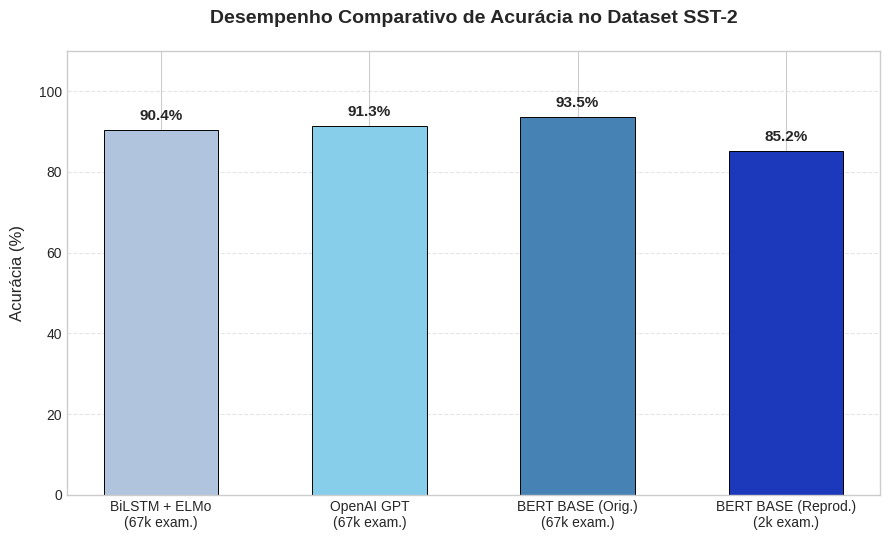

🚀 Ficheiro 'comparacao_resultados.png' guardado com sucesso no diretório local do Colab!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- AJUSTE AQUI ---
# Substitua o valor 85.2 pelo número exato obtido na Célula 5 do seu Colab
sua_acuracia = 85.2
# --------------------

# Dados extraídos diretamente da Tabela 1 do artigo do BERT
modelos = [
    'BiLSTM + ELMo\n(67k exam.)',
    'OpenAI GPT\n(67k exam.)',
    'BERT BASE (Orig.)\n(67k exam.)',
    'BERT BASE (Reprod.)\n(2k exam.)'
]
acuracias = [90.4, 91.3, 93.5, sua_acuracia]

# Configuração estética profissional (padrão de publicação académica)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(9, 5.5))

# Paleta de cores sóbria para artigos
cores = ['#B0C4DE', '#87CEEB', '#4682B4', '#1C39BB']

# Construção das barras
barras = ax.bar(modelos, acuracias, color=cores, width=0.55, edgecolor='black', linewidth=0.7)

# Ajustes de eixos e títulos
ax.set_title('Desempenho Comparativo de Acurácia no Dataset SST-2', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Acurácia (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, 110) # Espaço no topo para os rótulos de texto

# Adicionar os valores exatos no topo de cada barra para clareza visual
for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 5),  # 5 pontos de deslocamento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Refinamento do layout gráfico
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Guarda a imagem em alta definição para o Overleaf
plt.savefig('comparacao_resultados.png', dpi=300)
plt.show()
print("🚀 Ficheiro 'comparacao_resultados.png' guardado com sucesso no diretório local do Colab!")

# TP FINAL: Parte  2 - Melhorando Modelo

Desligando o aprendizado das 8 primeiras camadas , deixando apenas as restantes se modificarem, inicialmente com as 2000.

In [ ]:
# Célula 1: Instalação e Importações
!pip install -q transformers datasets evaluate accelerate scikit-learn
import torch
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import time

# 1. Carregando o Dataset e o Tokenizador
dataset = load_dataset("nyu-mll/glue", "sst2")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    # Mantemos max_length=128 para eficiência
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 2. Carregando o Modelo Base
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# =====================================================================
# 3. A MODIFICAÇÃO SIGNIFICATIVA (Layer Freezing / Congelamento)
# =====================================================================
print("Aplicando congelamento de camadas...")

# Congela a camada de Embeddings iniciais
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# O BERT base tem 12 camadas (0 a 11). Vamos congelar as 8 primeiras (0 a 7).
# Isso força o modelo a manter as regras gerais do idioma intactas e
# treinar apenas as últimas 4 camadas para focar no "sentimento" (Positivo/Negativo).
camadas_para_congelar = 8

for i in range(camadas_para_congelar):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = False

print(f"✅ Primeiras {camadas_para_congelar} camadas do BERT foram congeladas!")
# =====================================================================

# 4. Métrica
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 5. Configurando os hiperparâmetros (Igual ao TPF-01 para comparação justa)
training_args = TrainingArguments(
    output_dir="./resultados_bert_congelado",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
)

# 6. Definindo a quantidade de dados
# PARA O MODELO A: Use range(2000)
QTD_AMOSTRAS = 2000
dataset_treino = tokenized_datasets["train"].shuffle(seed=42).select(range(QTD_AMOSTRAS))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_treino,
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# 7. Executando e cronometrando
print(f"\nIniciando treinamento com {QTD_AMOSTRAS} amostras...")
inicio = time.time()
trainer.train()
fim = time.time()

# 8. Resultados
resultados = trainer.evaluate()
print("-" * 50)
print(f"📊 RESULTADOS (Congelando {camadas_para_congelar} camadas | {QTD_AMOSTRAS} dados) 📊")
print("-" * 50)
print(f"Acurácia: {resultados['eval_accuracy'] * 100:.2f}%")
print(f"Loss: {resultados['eval_loss']:.4f}")
print(f"Tempo de Treino: {(fim - inicio)/60:.2f} minutos")
print("-" * 50)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...


Iniciando treinamento com 2000 amostras...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.387515,0.841743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy
No log,0.387515,1,0.841743


--------------------------------------------------
📊 RESULTADOS (Congelando 8 camadas | 2000 dados) 📊
--------------------------------------------------
Acurácia: 84.17%
Loss: 0.3875
Tempo de Treino: 0.72 minutos
--------------------------------------------------


Salvando modelo Modificado A (primeira versao) com apenas 2000 dados de treinamento usados

In [ ]:
import os
from google.colab import drive

# 1. Monta o Google Drive
drive.mount('/content/drive')

# 2. Define o caminho exato para o Modelo A (Congelado, 2k dados)
caminho_modelo_a = '/content/drive/MyDrive/RedesNeurais/Bert/Modificado_A_2k/'

# 3. Cria a pasta se ela ainda não existir
os.makedirs(caminho_modelo_a, exist_ok=True)

# 4. Guarda o modelo e o tokenizador
trainer.save_model(caminho_modelo_a)
tokenizer.save_pretrained(caminho_modelo_a)

print(f"✅ Sucesso! Modelo Modificado A salvo com segurança em: {caminho_modelo_a}")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Sucesso! Modelo Modificado A salvo com segurança em: /content/drive/MyDrive/RedesNeurais/Bert/Modificado_A_2k/


## Modelo Alterado 2

Aqui não so usamos o congelamento das 8 primeiras camadas do modelo e retreinamos as demais, como agora podemos aumentar o numero de dados sem que haja um gargalo de tempo, ja que temos agora menos camadas.

In [ ]:
# Célula 1: Instalação e Importações
!pip install -q transformers datasets evaluate accelerate scikit-learn
import torch
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import time

# 1. Carregando o Dataset e o Tokenizador
dataset = load_dataset("nyu-mll/glue", "sst2")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    # Mantemos max_length=128 para eficiência
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 2. Carregando o Modelo Base
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# =====================================================================
# 3. A MODIFICAÇÃO SIGNIFICATIVA (Layer Freezing / Congelamento)
# =====================================================================
print("Aplicando congelamento de camadas...")

# Congela a camada de Embeddings iniciais
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# O BERT base tem 12 camadas (0 a 11). Vamos congelar as 8 primeiras (0 a 7).
# Isso força o modelo a manter as regras gerais do idioma intactas e
# treinar apenas as últimas 4 camadas para focar no "sentimento" (Positivo/Negativo).
camadas_para_congelar = 8

for i in range(camadas_para_congelar):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = False

print(f"✅ Primeiras {camadas_para_congelar} camadas do BERT foram congeladas!")
# =====================================================================

# 4. Métrica
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 5. Configurando os hiperparâmetros (Igual ao TPF-01 para comparação justa)
training_args = TrainingArguments(
    output_dir="./resultados_bert_congelado",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
)

# 6. Definindo a quantidade de dados
# PARA O MODELO B: Mude para range(20000)
QTD_AMOSTRAS = 20000
dataset_treino = tokenized_datasets["train"].shuffle(seed=42).select(range(QTD_AMOSTRAS))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_treino,
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# 7. Executando e cronometrando
print(f"\nIniciando treinamento com {QTD_AMOSTRAS} amostras...")
inicio = time.time()
trainer.train()
fim = time.time()

# 8. Resultados
resultados = trainer.evaluate()
print("-" * 50)
print(f"📊 RESULTADOS (Congelando {camadas_para_congelar} camadas | {QTD_AMOSTRAS} dados) 📊")
print("-" * 50)
print(f"Acurácia: {resultados['eval_accuracy'] * 100:.2f}%")
print(f"Loss: {resultados['eval_loss']:.4f}")
print(f"Tempo de Treino: {(fim - inicio)/60:.2f} minutos")
print("-" * 50)

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Aplicando congelamento de camadas...
✅ Primeiras 8 camadas do BERT foram congeladas!

Iniciando treinamento com 20000 amostras...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.306580,0.251882,0.905963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy
0.306580,0.251882,1,0.905963


--------------------------------------------------
📊 RESULTADOS (Congelando 8 camadas | 20000 dados) 📊
--------------------------------------------------
Acurácia: 90.60%
Loss: 0.2519
Tempo de Treino: 4.59 minutos
--------------------------------------------------


salvando o modelo B

In [ ]:
import os
from google.colab import drive

# 1. Garante que o Google Drive está montado
drive.mount('/content/drive')

# 2. Define o novo caminho exato para o Modelo B (Congelado, 20k dados)
caminho_modelo_b = '/content/drive/MyDrive/RedesNeurais/Bert/Modificado_B_20k/'

# 3. Cria a pasta se ela ainda não existir
os.makedirs(caminho_modelo_b, exist_ok=True)

# 4. Guarda o modelo e o tokenizador
trainer.save_model(caminho_modelo_b)
tokenizer.save_pretrained(caminho_modelo_b)

print(f"✅ Sucesso! Modelo Modificado B salvo com segurança em: {caminho_modelo_b}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Sucesso! Modelo Modificado B salvo com segurança em: /content/drive/MyDrive/RedesNeurais/Bert/Modificado_B_20k/


## Comparativo de Modelos


1.   Original
2.   Modificado_A (modificando as 4 ultimas camadas e com 2000 dados de treinamento)
3.   Modificado_B (modificando as 4 ultimas camadas e com 20000 dados de treinamento)



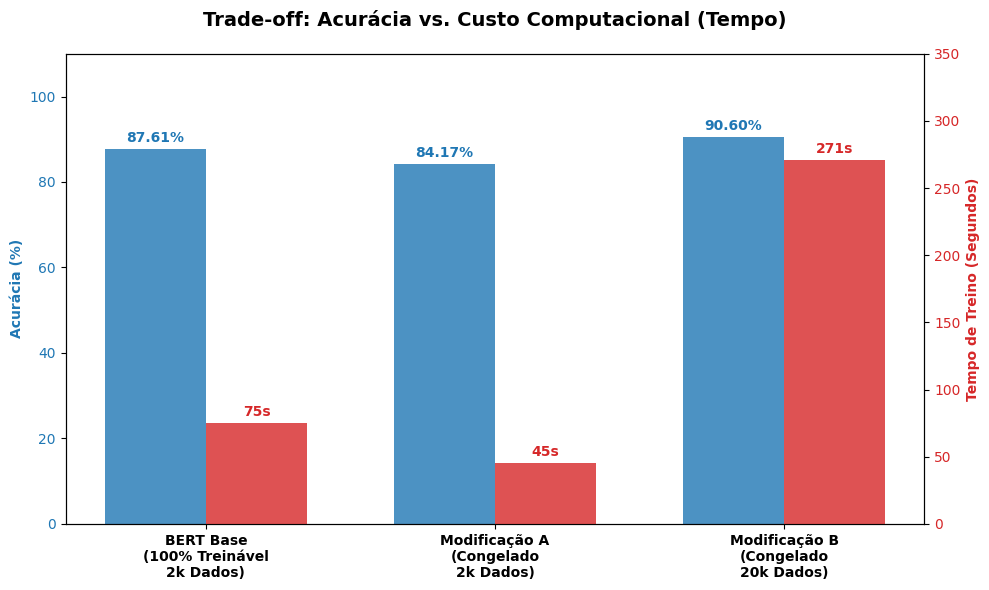

✅ Gráfico 'grafico_tpf02.png' gerado com sucesso! Faça o download para o Overleaf.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Acurácias em porcentagem (%)
acuracia_base = 87.61
acuracia_mod_A = 84.17
acuracia_mod_B = 90.60

# Tempos de treinamento em SEGUNDOS
tempo_base = 75       # (1.25 min)
tempo_mod_A = 45      # (0.75 min)
tempo_mod_B = 271     # (4.51 min)

modelos = ['BERT Base\n(100% Treinável\n2k Dados)',
           'Modificação A\n(Congelado\n2k Dados)',
           'Modificação B\n(Congelado\n20k Dados)']

acuracias = [acuracia_base, acuracia_mod_A, acuracia_mod_B]
tempos = [tempo_base, tempo_mod_A, tempo_mod_B]

x = np.arange(len(modelos))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo 1: Acurácia (Barras Azuis)
color = 'tab:blue'
ax1.set_ylabel('Acurácia (%)', color=color, fontweight='bold')
barras_acc = ax1.bar(x - width/2, acuracias, width, label='Acurácia', color=color, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 110) # Aumentei um pouco o limite para caber o texto confortavelmente

# Adicionando os valores em cima das barras azuis
for barra in barras_acc:
    height = barra.get_height()
    ax1.annotate(f'{height:.2f}%', xy=(barra.get_x() + barra.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', color=color, fontweight='bold')

# Eixo 2: Tempo de Treino (Barras Vermelhas)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Tempo de Treino (Segundos)', color=color, fontweight='bold')
barras_tempo = ax2.bar(x + width/2, tempos, width, label='Tempo (s)', color=color, alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 350) # Ajuste de limite para os segundos

# Adicionando os valores em cima das barras vermelhas
for barra in barras_tempo:
    height = barra.get_height()
    ax2.annotate(f'{height:.0f}s', xy=(barra.get_x() + barra.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', color=color, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontweight='bold')
plt.title('Trade-off: Acurácia vs. Custo Computacional (Tempo)', pad=20, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.savefig('grafico_tpf02.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico 'grafico_tpf02.png' gerado com sucesso! Faça o download para o Overleaf.")

# testes praticos:

In [ ]:
from transformers import pipeline

print("Carregando os modelos do Google Drive... (Isso pode levar alguns segundos)\n")

# 1. Definição dos caminhos no seu Drive
# NOTA: O caminho_base assume que você salvou o modelo do TPF-01 na pasta raiz 'Bert/'.
# Ajuste se estiver em uma subpasta!
caminhos = {
    "Modelo Base (TPF-01 - 2k dados)": '/content/drive/MyDrive/RedesNeurais/Bert/',
    "Modificação A (Congelado - 2k dados)": '/content/drive/MyDrive/RedesNeurais/Bert/Modificado_A_2k/',
    "Modificação B (Congelado - 20k dados)": '/content/drive/MyDrive/RedesNeurais/Bert/Modificado_B_20k/'
}

# Carrega os classificadores usando a GPU (device=0) se disponível
classificadores = {}
for nome, caminho in caminhos.items():
    classificadores[nome] = pipeline("text-classification", model=caminho, tokenizer=caminho, device=0)

# 2. Suas Strings de Teste
# Coloquei frases claras, uma pegadinha e uma do seu domínio de sistemas distribuídos!
frases_teste = [
    "The simulation results exceeded our initial expectations, brilliant architecture!", # Domínio Técnico (Positiva)
    "What a complete waste of time, the execution was flawed and terribly slow.",      # Negativa Clara
    "It's not that the algorithm was bad, but the logic made absolutely no sense.",    # Pegadinha (Negativa com palavras boas)
    "A truly masterpiece of engineering, I loved every single feature."                  # Positiva Clara
]

# Função auxiliar para traduzir a saída (LABEL_1 = Positivo, LABEL_0 = Negativo)
def formatar_saida(resultado):
    label = "POSITIVO" if resultado['label'] == 'LABEL_1' else "NEGATIVO"
    confianca = resultado['score'] * 100
    return f"{label} ({confianca:.1f}% de certeza)"

# 3. Executando o comparativo
print("=" * 80)
print("🔍 INICIANDO O TESTE COMPARATIVO 🔍")
print("=" * 80)

for frase in frases_teste:
    print(f"\n📝 Texto: '{frase}'\n")

    for nome_modelo, classificador in classificadores.items():
        # Faz a previsão
        previsao = classificador(frase)[0]

        # Formata a exibição
        texto_formatado = formatar_saida(previsao)
        print(f"   ➤ {nome_modelo:<40}: {texto_formatado}")

    print("-" * 80)

Carregando os modelos do Google Drive... (Isso pode levar alguns segundos)



Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

🔍 INICIANDO O TESTE COMPARATIVO 🔍

📝 Texto: 'The simulation results exceeded our initial expectations, brilliant architecture!'

   ➤ Modelo Base (TPF-01 - 2k dados)         : POSITIVO (88.6% de certeza)
   ➤ Modificação A (Congelado - 2k dados)    : POSITIVO (84.1% de certeza)
   ➤ Modificação B (Congelado - 20k dados)   : POSITIVO (99.2% de certeza)
--------------------------------------------------------------------------------

📝 Texto: 'What a complete waste of time, the execution was flawed and terribly slow.'

   ➤ Modelo Base (TPF-01 - 2k dados)         : NEGATIVO (84.2% de certeza)
   ➤ Modificação A (Congelado - 2k dados)    : NEGATIVO (86.9% de certeza)
   ➤ Modificação B (Congelado - 20k dados)   : NEGATIVO (98.1% de certeza)
--------------------------------------------------------------------------------

📝 Texto: 'It's not that the algorithm was bad, but the logic made absolutely no sense.'

   ➤ Modelo Base (TPF-01 - 2k dados)         : NEGATIVO (82.7% de certeza)
   ➤ M

## TESTE PARA SALA DE AULA:

In [ ]:
from transformers import pipeline
from IPython.display import clear_output  # Importação para limpar a tela no Colab

print("Carregando os modelos do Google Drive... (Isso pode levar alguns segundos)\n")

# 1. Definição dos caminhos no seu Drive
caminhos = {
    "Modelo Base (TPF-01 - 2k dados)": '/content/drive/MyDrive/RedesNeurais/Bert/',
    "Modificação A (Congelado - 2k dados)": '/content/drive/MyDrive/RedesNeurais/Bert/Modificado_A_2k/',
    "Modificação B (Congelado - 20k dados)": '/content/drive/MyDrive/RedesNeurais/Bert/Modificado_B_20k/'
}

# Carrega os classificadores usando a GPU (device=0) se disponível
classificadores = {}
for nome, caminho in caminhos.items():
    classificadores[nome] = pipeline("text-classification", model=caminho, tokenizer=caminho, device=0)

# Função auxiliar para traduzir a saída
def formatar_saida(resultado):
    label = "POSITIVO" if resultado['label'] == 'LABEL_1' else "NEGATIVO"
    confianca = resultado['score'] * 100
    return f"{label} ({confianca:.1f}% de certeza)"

# 2. Loop Interativo
while True:
    # Limpa a saída da célula antes de pedir a nova frase
    clear_output(wait=True)

    print("=" * 80)
    print("TESTE INTERATIVO COMPARATIVO DE MODELOS BERT")
    print("   (Digite 'sair' ou 'exit' para encerrar o teste)")
    print("=" * 80)

    # Coleta a frase do usuário
    frase = input("\n Digite a frase em inglês para análise: ")

    # Condição de parada
    if frase.strip().lower() in ['sair', 'exit']:
        print("\nEncerrando o teste interativo. Excelente trabalho!")
        break

    # Evita que o usuário aperte enter sem digitar nada
    if not frase.strip():
        continue

    print("\nAnalisando...\n")

    # Passa a frase pelos 3 modelos
    for nome_modelo, classificador in classificadores.items():
        previsao = classificador(frase)[0]
        texto_formatado = formatar_saida(previsao)
        print(f"   ➤ {nome_modelo:<40}: {texto_formatado}")

    print("-" * 80)

    # Pausa a execução esperando o usuário apertar Enter para a próxima rodada
    input("\nPressione [ENTER] para limpar a tela e testar uma nova frase...")

Carregando os modelos do Google Drive... (Isso pode levar alguns segundos)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TESTE INTERATIVO COMPARATIVO DE MODELOS BERT
   (Digite 'sair' ou 'exit' para encerrar o teste)

Analisando...

   ➤ Modelo Base (TPF-01 - 2k dados)         : NEGATIVO (85.8% de certeza)
   ➤ Modificação A (Congelado - 2k dados)    : NEGATIVO (83.4% de certeza)
   ➤ Modificação B (Congelado - 20k dados)   : NEGATIVO (98.1% de certeza)
--------------------------------------------------------------------------------
TESTE INTERATIVO COMPARATIVO DE MODELOS BERT
   (Digite 'sair' ou 'exit' para encerrar o teste)

Analisando...

   ➤ Modelo Base (TPF-01 - 2k dados)         : POSITIVO (86.6% de certeza)
   ➤ Modificação A (Congelado - 2k dados)    : POSITIVO (79.0% de certeza)
   ➤ Modificação B (Congelado - 20k dados)   : POSITIVO (98.9% de certeza)
--------------------------------------------------------------------------------
TESTE INTERATIVO COMPARATIVO DE MODELOS BERT
   (Digite 'sair' ou 'exit' para encerrar o teste)

Analisando...

   ➤ Modelo Base (TPF-01 - 2k dados)         : NEGAT